In [1]:
import h5py
import numpy as np
import pandas as pd

from HighLevelFeatures import HighLevelFeatures as HLF
import matplotlib.pyplot as plt

In [29]:
HLF_ref = HLF("photon", filename="../binning_dataset_1_photons.xml")
HLF_sim = HLF("photon", filename="../binning_dataset_1_photons.xml")

In [32]:
ref_file = "/pscratch/sd/p/pmtuan/calochallenge/ds1-photons/caloINN_sample.hdf5"

with h5py.File(ref_file, "r") as f:
    ref_data = {
        key: val[:] for key, val in f.items()
    }
    mask = (f["incident_energies"][:] == 16384.).squeeze()
    HLF_ref.CalculateFeatures(f["showers"][mask])

In [33]:
sim_file = "/global/cfs/cdirs/m3443/usr/pmtuan/ddsim_caloxtreme/run/electron_25k_10-50GeV/el_vx.hdf5"

with h5py.File(sim_file, "r") as f:
    sim_data = {
        key: val[:] for key, val in f.items()
    }
    HLF_sim.CalculateFeatures(f["showers"][:])

In [34]:
# total deposited energy in the shower
print("Total energy of each photon shower: ", HLF_ref.GetEtot())
print("Average total energy of the photon showers: ", HLF_ref.GetEtot().mean())

# total deposited energy in the shower
print("Total energy of each photon shower: ", HLF_sim.GetEtot())
print("Average total energy of the photon showers: ", HLF_sim.GetEtot().mean())
energy_ratio = (HLF_sim.GetEtot() / sim_data['incident_energies'].flatten() )
print(f"Percentage of energy deposited compared to incident energy: {energy_ratio.mean() * 100 : .2f} +/- {energy_ratio.std() * 100 : .2f}%")


Total energy of each photon shower:  [16003.40700848 16110.21756048 15842.56520403 ... 15996.08864877
 15911.36696506 15961.70388157]
Average total energy of the photon showers:  15992.46266071827
Total energy of each photon shower:  [1178.65721906  585.45063317  958.32571558 ...  346.00747401  895.21628349
  886.65482056]
Average total energy of the photon showers:  797.259104091174
Percentage of energy deposited compared to incident energy:  2.66 +/-  0.09%


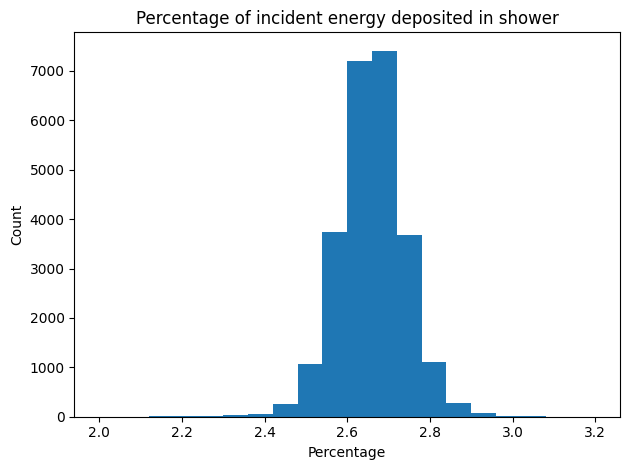

In [35]:
fig, ax = plt.subplots(1,1)

ax.hist(energy_ratio *100, bins=20, range=(2,3.2))
ax.set_title("Percentage of incident energy deposited in shower")
ax.set_xlabel("Percentage")
ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

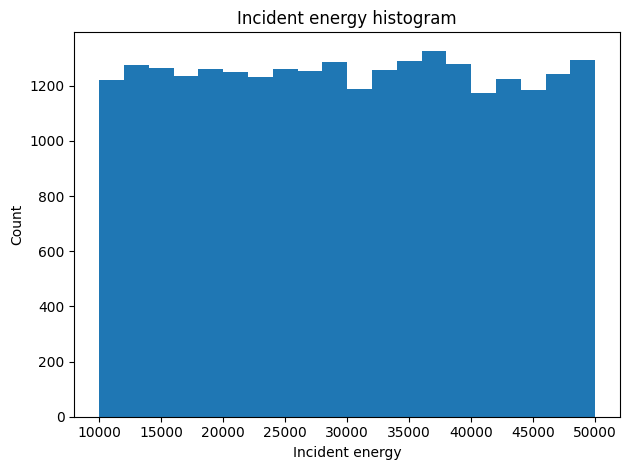

In [36]:
fig, ax = plt.subplots(1,1)

ax.hist(sim_data['incident_energies'], bins=20)
ax.set_title("Incident energy histogram")
ax.set_xlabel("Incident energy")
ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

In [23]:
E = 16384.

mask = np.array(ref_data['incident_energies']) == E
mask = mask.flatten()

ref_showers = np.array(ref_data['showers'])[mask]

ref_showers.max(), ref_showers.mean(), ref_showers.std()

(np.float64(11111.461617564233),
 np.float64(23.37622210480391),
 np.float64(90.90242099675262))

In [24]:
E = 16384.

mask = np.array(sim_data['incident_energies']) == E
mask = mask.flatten()

sim_showers = np.array(sim_data['showers'])[mask]

sim_showers.max(), sim_showers.mean(), sim_showers.std()

(np.float32(331.83734), np.float32(0.30273035), np.float32(4.1888657))